In [12]:
import pandas as pd
import numpy as np

In [13]:
import pandas as pd
import seaborn as sns

In [14]:
#https://www.kaggle.com/datasets/sonalshinde123/student-placement-dataset
from pandas import read_csv
df=read_csv('C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\titanic.csv')

In [15]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


C:\Users\vippa\AppData\Local\Temp\ipykernel_30984\1869842994.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [16]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [17]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


# Correlation Heatmap

To identify the relationship among numerical features and understand which variables are positively or negatively correlated before model development.
A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally,

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

##Example:

# **1. Coding Skills vs Certifications = 0.86**
Observation
-A strong positive relationship exists.
-Students with better coding skills usually earn more certifications.
-Certifications appear to reflect technical competency.


# 2. Student_ID, Correlation ≈ 0
Observation

- It has no relationship with placement or academic performance.
- It should be removed before model training.

#3.CGPA vs Backlogs = -0.58
    -As CGPA increases, the number of backlogs generally decreases.

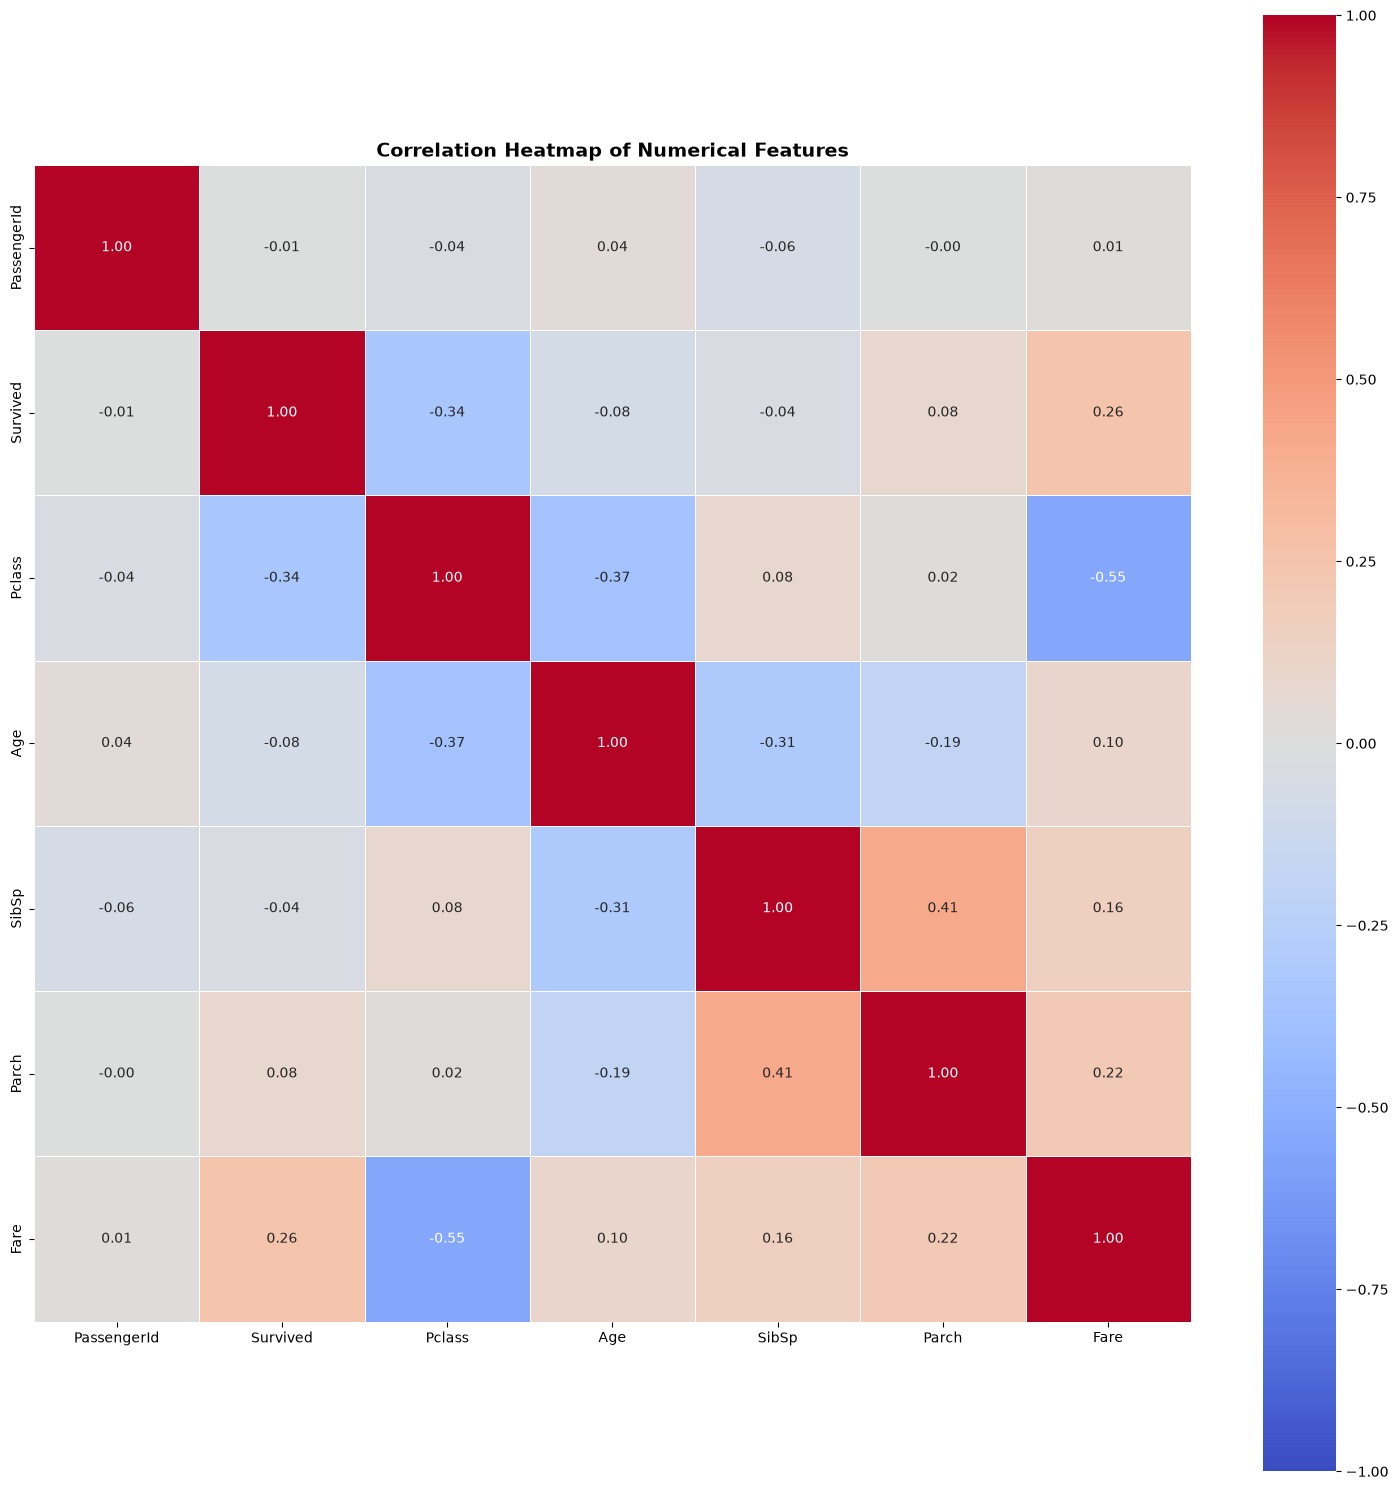

In [18]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [19]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

# Export Heatmap
import os
output_dir = "C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\outputs"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\correlation_heatmap.png


In [20]:

print(os.getcwd())

c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\notebooks


In [25]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs Survived (Target)
# -------------------------------------------------------------
target_col = "Survived"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()
        

        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")
else:
    print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

print("\nAll EDA tasks completed successfully!")

Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_PassengerId_vs_Survived.png
Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_Survived_vs_Survived.png
Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_Pclass_vs_Survived.png
Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_Age_vs_Survived.png
Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_SibSp_vs_Survived.png
Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_Parch_vs_Survived.png
Exported boxplot to: C:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\outputs\boxplot_Fare_vs_Survived.png

All EDA tasks completed successfully!


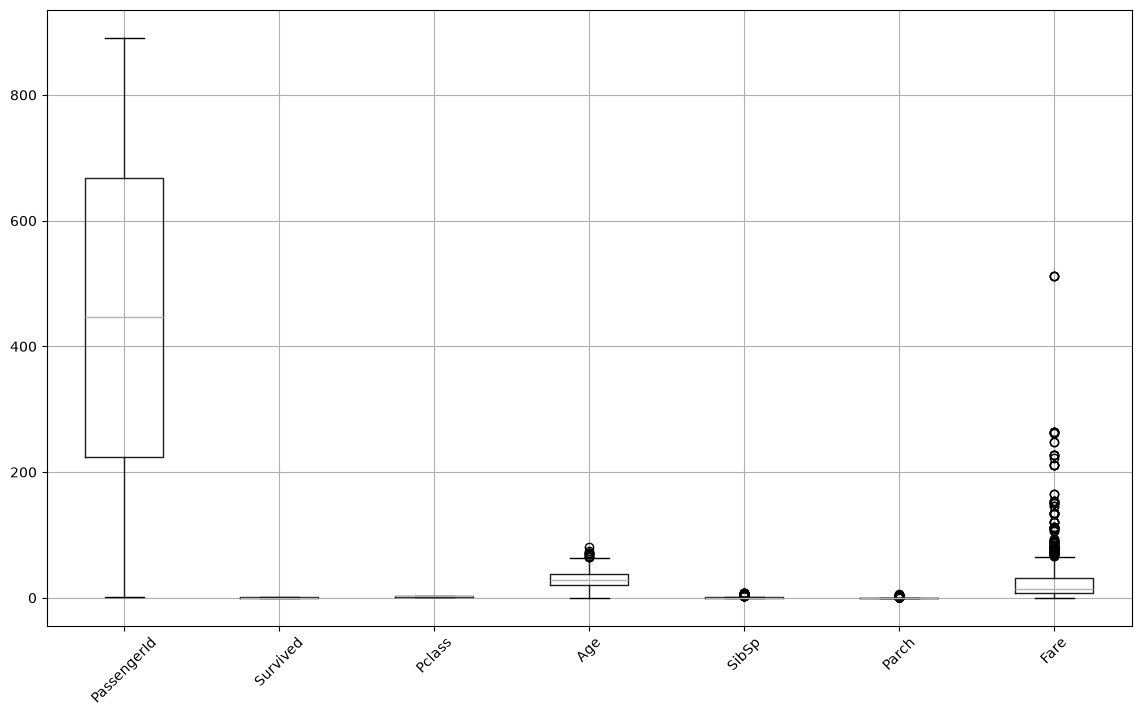

In [23]:
#boxplots
numerical_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
    
]


fig6= plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

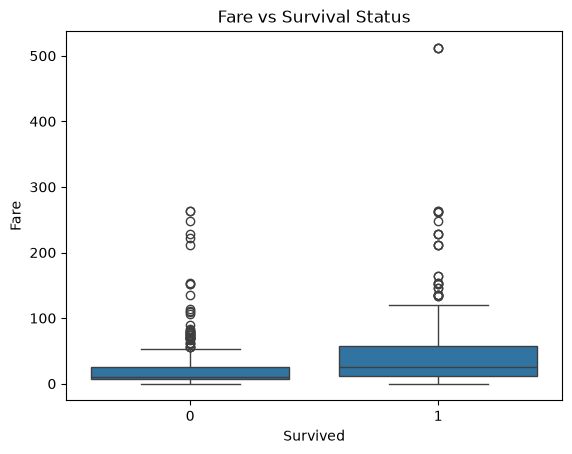

In [26]:
fig7 = sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival Status')
plt.show()

In [28]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:
    # Save the available figures
    pdf.savefig(fig6)
    

print("EDA Report saved successfully.")

EDA Report saved successfully.


In [29]:
#==========================================================
# Export Complete EDA Report
#==========================================================

with PdfPages("EDA_Report.pdf") as pdf:

    #------------------------------------------------------
    # Page 1 : Missing Value Heatmap
    #------------------------------------------------------

    plt.figure(figsize=(12,6))

    sns.heatmap(df.isnull(),
                cbar=True,
                yticklabels=False,
                cmap="viridis")

    plt.title("Missing Value Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 2 : Histograms (6 Features)
    #------------------------------------------------------

    numerical_features = [
        "PassengerId",
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare"
    ]

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i,col in enumerate(numerical_features):

        axes[i].hist(df[col],
                     bins=15,
                     edgecolor='black')

        axes[i].set_title(col)

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 3 : Survival by Passenger Class
    #------------------------------------------------------

    plt.figure(figsize=(10,6))

    sns.countplot(
        data=df,
        x="Pclass",
        hue="Survived"
    )

    plt.title("Survival Status by Passenger Class")

    plt.xticks(rotation=45)

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 4 : Correlation Heatmap
    #------------------------------------------------------

    plt.figure(figsize=(10,8))

    corr = df.select_dtypes(include=np.number).corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    pdf.savefig()

    plt.close()


    #------------------------------------------------------
    # Page 5 : Boxplots
    #------------------------------------------------------

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i,col in enumerate(numerical_features):

        sns.boxplot(
            y=df[col],
            ax=axes[i]
        )

        axes[i].set_title(col)

    plt.tight_layout()

    pdf.savefig()

    plt.close()

print("EDA_Report.pdf created successfully.")

EDA_Report.pdf created successfully.
